# ROC-Based Predictive Analysis: 30-Day Price Movement Classification

This notebook implements a data science workflow to predict 30-day price movements using Rate of Change (ROC) indicator.

**Objective:** Create a binary classification target where:
- `1` = Positive ROC (price increase over 30 days)
- `0` = Non-positive ROC (price stagnation or decrease over 30 days)

## Initial imports and basic settings

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve, auc)

##  Load pipeline output + scale

In [17]:
df = pd.read_csv('../model_data.csv')

df.head()

,Date,MACD_Signal,BB_Width,RSI_lag1,ATR_Pct,SMA20_Dist,Stoch_K,ROC_roll5_mean,Volume_Ratio,CCI,Price_Direction_30d
0,1999-04-05,0.000043,0.165902,53.267613,0.070849,-0.035639,59.007924,-0.794889,1.096819,-2430.159359,0
1,1999-04-06,-0.000018,0.171081,50.304723,0.071632,-0.055301,43.711443,-3.070597,0.777656,-2246.215563,1
2,1999-04-07,-0.000038,0.157911,48.005570,0.067320,0.026581,48.084269,-2.457141,1.027057,-2462.768192,0
3,1999-04-08,-0.000019,0.153657,55.179098,0.065174,0.045705,61.198544,-1.357794,1.593394,-2537.529485,0
4,1999-04-09,0.000012,0.154960,56.664675,0.063724,0.026737,75.403923,0.664012,0.597464,-2526.145480,0


In [28]:
FEATURES = ['MACD_Signal', 'BB_Width', 'RSI_lag1', 'ATR_Pct', 'SMA20_Dist', 'Stoch_K', 'ROC_roll5_mean', 'Volume_Ratio', 'CCI']
TARGET = 'Price_Direction_30d'

X = df[FEATURES]
y = df[TARGET]

# Chronological split — no shuffle to avoid future leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, shuffle=False)

print(f"Train: {len(X_train)}  Test: {len(X_test)}")
print(f"\nTrain class balance:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest class balance:\n{y_test.value_counts(normalize=True).round(3)}")

Train: 5481  Test: 968

Train class balance:
Price_Direction_30d
1    0.613
0    0.387
Name: proportion, dtype: float64

Test class balance:
Price_Direction_30d
1    0.65
0    0.35
Name: proportion, dtype: float64


## Feature distributions by class

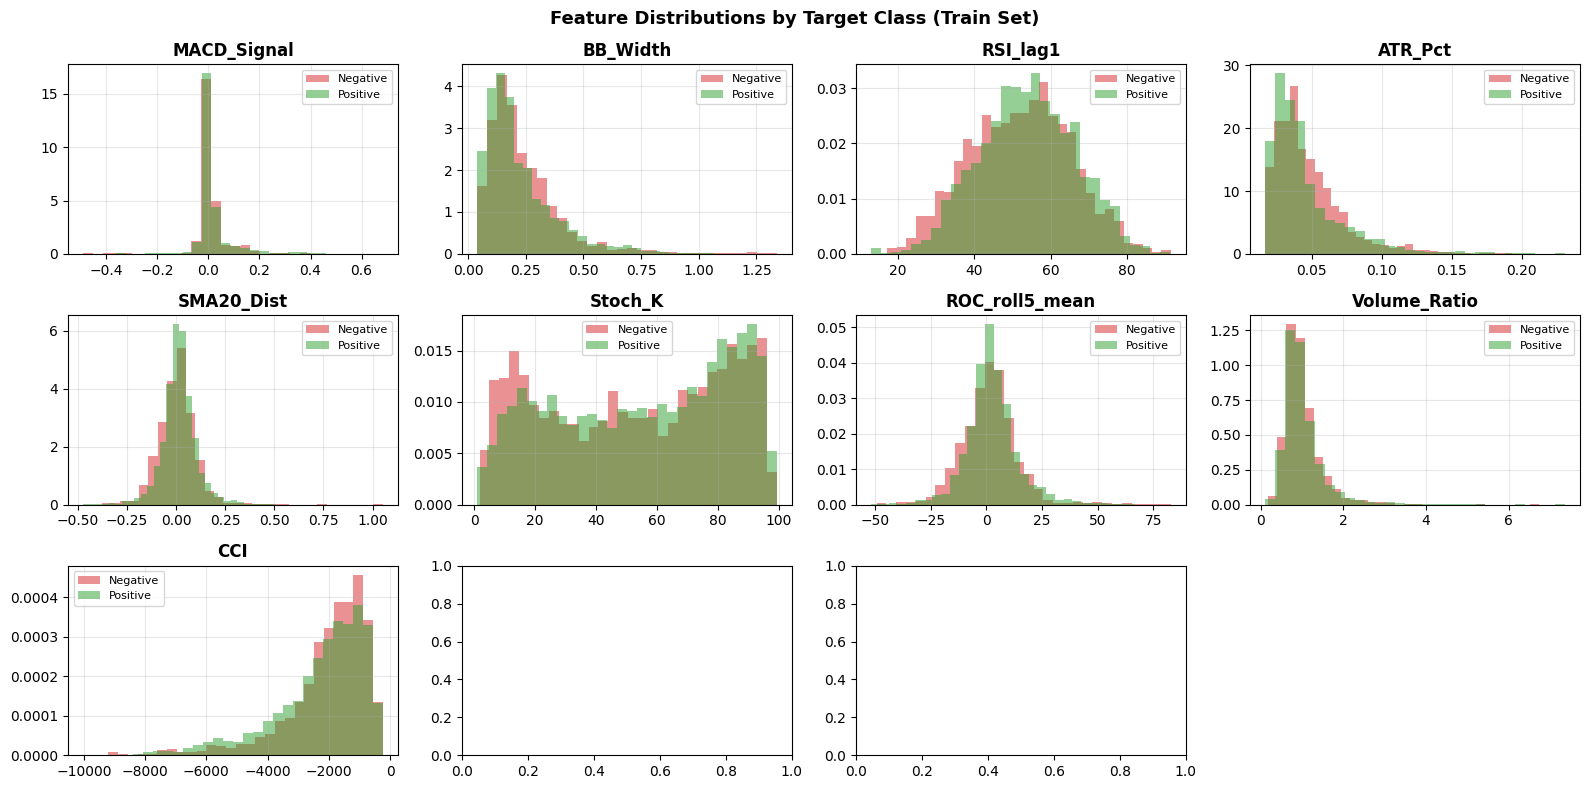

In [29]:
fig, axes = plt.subplots(3, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    for label, color, name in [(0, '#d62728', 'Negative'), (1, '#2ca02c', 'Positive')]:
        vals = X_train[feat][y_train == label]
        axes[i].hist(vals, bins=30, alpha=0.5, color=color, label=name, density=True)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

axes[-1].set_visible(False)
fig.suptitle('Feature Distributions by Target Class (Train Set)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## Train with RandomizedSearchCV

In [34]:
tscv = TimeSeriesSplit(n_splits=5)

rf = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')

param_dist = {
    'n_estimators':      [200, 300, 500],
    'max_depth':         [4, 6, 8],
    'min_samples_split': [15, 25, 40],
    'min_samples_leaf':  [20, 30, 40],
    'max_features':      ['sqrt', 'log2'],
    'bootstrap':         [True],        
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

print("\nBest parameters:")
for k, v in rf_search.best_params_.items():
    print(f"  {k:<22} {v}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best parameters:
  n_estimators           500
  min_samples_split      15
  min_samples_leaf       20
  max_features           sqrt
  max_depth              6
  bootstrap              True


##  Performance across all splits

In [35]:
y_train_pred = best_rf.predict(X_train)
y_test_pred = best_rf.predict(X_test)
y_test_proba = best_rf.predict_proba(X_test)[:, 1]

metrics = {
    'Accuracy' : accuracy_score,
    'Precision': precision_score,
    'Recall'   : recall_score,
    'F1-Score' : f1_score,
}

print(f"\n{'Metric':<12} {'Train':>10} {'Test':>10}")
print("-" * 45)
for name, fn in metrics.items():
    tr = fn(y_train, y_train_pred)
    te = fn(y_test,  y_test_pred)
    print(f"{name:<12} {tr:>10.4f} {te:>10.4f}")

print(f"{'ROC-AUC':<12} {'—':>10} {roc_auc_score(y_test, y_test_proba):>10.4f}")

gap = accuracy_score(y_train, y_train_pred) - accuracy_score(y_test, y_test_pred)
print(f"\nOverfitting gap (train − test accuracy): {gap:.4f}")


Metric            Train       Test
---------------------------------------------
Accuracy         0.6993     0.6033
Precision        0.7899     0.6748
Recall           0.6945     0.7520
F1-Score         0.7392     0.7113
ROC-AUC               —     0.5254

Overfitting gap (train − test accuracy): 0.0960


## Confusion matrix + ROC curve

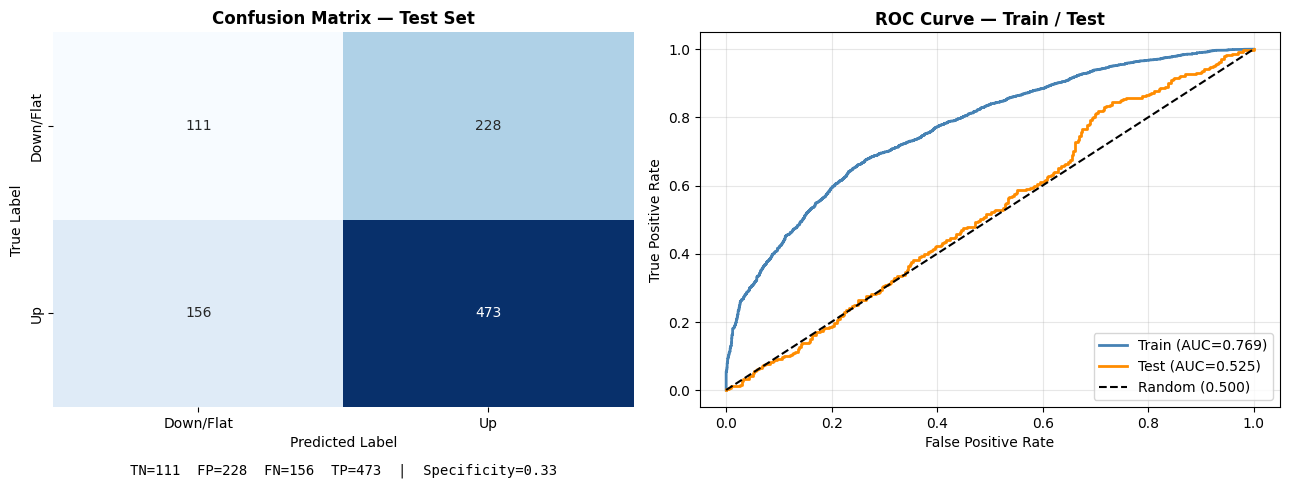

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Down/Flat', 'Up'],
            yticklabels=['Down/Flat', 'Up'])
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].set_title('Confusion Matrix — Test Set', fontweight='bold')
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
axes[0].text(0.5, -0.18,
             f'TN={tn}  FP={fp}  FN={fn}  TP={tp}  |  Specificity={specificity:.2f}',
             transform=axes[0].transAxes, ha='center', fontsize=10, family='monospace')

# ROC — distinct colours, no unused X_sc variable
for y_true, y_prob, label, color, ls in [
    (y_train, best_rf.predict_proba(X_train)[:, 1], 'Train', 'steelblue',  '-'),
    (y_test,  y_test_proba,                         'Test',  'darkorange', '-'),
]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    axes[1].plot(fpr, tpr, lw=2, label=f'{label} (AUC={auc:.3f})',
                 color=color, linestyle=ls)

axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random (0.500)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Train / Test', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Feature importance

       Feature  Importance
   MACD_Signal    0.244425
       ATR_Pct    0.204164
      BB_Width    0.111251
           CCI    0.098074
    SMA20_Dist    0.090323
      RSI_lag1    0.078161
ROC_roll5_mean    0.074623
       Stoch_K    0.056428
  Volume_Ratio    0.042550


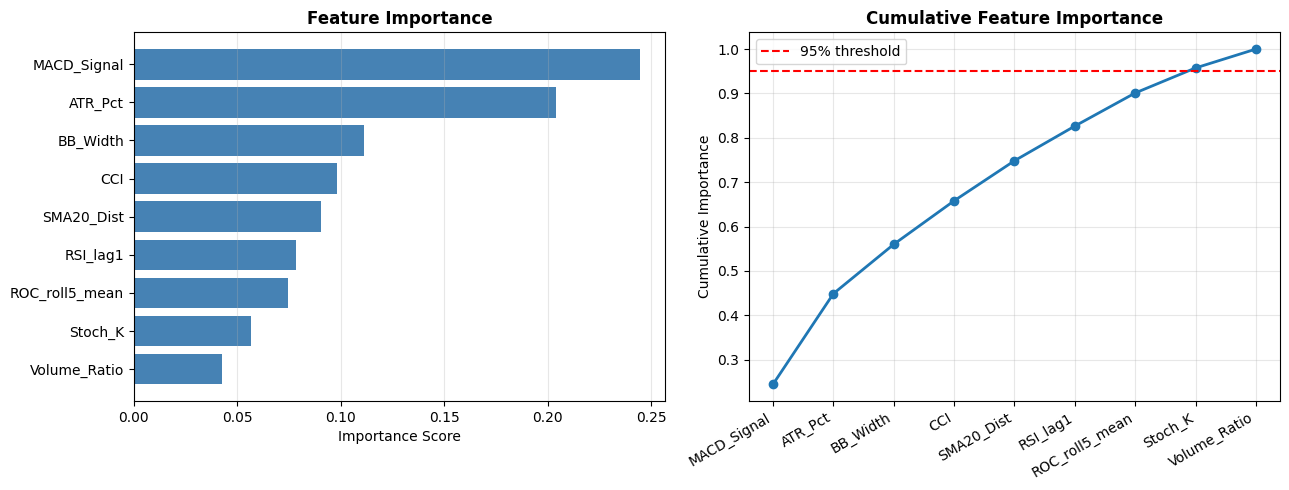


Features needed for 95% cumulative importance: 8


In [37]:
feat_imp = pd.DataFrame({
    'Feature':    FEATURES,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print(feat_imp.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(feat_imp['Feature'], feat_imp['Importance'], color='steelblue')
axes[0].invert_yaxis()
axes[0].set_xlabel('Importance Score')
axes[0].set_title('Feature Importance', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

cumsum = feat_imp['Importance'].cumsum()
axes[1].plot(range(1, len(cumsum) + 1), cumsum, marker='o', linewidth=2)
axes[1].axhline(0.95, color='red', linestyle='--', label='95% threshold')
axes[1].set_xticks(range(1, len(FEATURES) + 1))
axes[1].set_xticklabels(feat_imp['Feature'], rotation=30, ha='right')
axes[1].set_ylabel('Cumulative Importance')
axes[1].set_title('Cumulative Feature Importance', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

n_for_95 = int((cumsum >= 0.95).idxmax()) + 1
print(f"\nFeatures needed for 95% cumulative importance: {n_for_95}")

## Drop features that do not contribute that much (so leave 95% explanation power)

In [38]:
feat_imp_sorted = feat_imp.sort_values('Importance', ascending=False).reset_index(drop=True)
feat_imp_sorted['Cumulative'] = feat_imp_sorted['Importance'].cumsum()

# Find cutoff — first row where cumulative >= 0.95
cutoff_idx = (feat_imp_sorted['Cumulative'] >= 0.95).idxmax()
kept = feat_imp_sorted.loc[:cutoff_idx]
dropped = feat_imp_sorted.loc[cutoff_idx + 1:]

print("Features kept (95% cumulative importance):")
print(kept[['Feature', 'Importance', 'Cumulative']].to_string(index=False))

print(f"\nFeatures dropped (bottom 5% combined):")
print(dropped[['Feature', 'Importance', 'Cumulative']].to_string(index=False))
print(f"  Combined importance of dropped: {dropped['Importance'].sum()*100:.2f}%")

FEATURES_FINAL = kept['Feature'].tolist()

Features kept (95% cumulative importance):
       Feature  Importance  Cumulative
   MACD_Signal    0.244425    0.244425
       ATR_Pct    0.204164    0.448589
      BB_Width    0.111251    0.559840
           CCI    0.098074    0.657914
    SMA20_Dist    0.090323    0.748237
      RSI_lag1    0.078161    0.826399
ROC_roll5_mean    0.074623    0.901022
       Stoch_K    0.056428    0.957450

Features dropped (bottom 5% combined):
     Feature  Importance  Cumulative
Volume_Ratio     0.04255         1.0
  Combined importance of dropped: 4.26%


In [40]:
X2 = df[FEATURES_FINAL]
y2 = df[TARGET]

X2_temp, X2_test, y2_temp, y2_test = train_test_split(X2, y2, test_size=0.15, shuffle=False)
X2_train, X2_val, y2_train, y2_val = train_test_split(X2_temp, y2_temp, test_size=0.15/0.85, shuffle=False)

scaler2     = StandardScaler()
X2_train_sc = scaler2.fit_transform(X2_train)
X2_val_sc   = scaler2.transform(X2_val)
X2_test_sc  = scaler2.transform(X2_test)

tscv = TimeSeriesSplit(n_splits=5)

# Fresh hyperparameter search on reduced feature set
rf2 = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')

param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [4, 8, 10, None],
    'min_samples_split': [10, 15, 20, 30],
    'min_samples_leaf':  [12, 17, 23, 30],
    'max_features':      ['sqrt', 'log2', None],
    'bootstrap':         [True, False]
}

rf2_search = RandomizedSearchCV(
    estimator=rf2,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf2_search.fit(X2_train_sc, y2_train)
best_rf2 = rf2_search.best_estimator_

print("\nBest parameters (reduced model):")
for k, v in rf2_search.best_params_.items():
    print(f"  {k:<22} {v}")

y2_train_pred = best_rf2.predict(X2_train_sc)
y2_val_pred   = best_rf2.predict(X2_val_sc)
y2_test_pred  = best_rf2.predict(X2_test_sc)
y2_test_proba = best_rf2.predict_proba(X2_test_sc)[:, 1]

print("\n" + "=" * 55)
print("FULL MODEL vs REDUCED MODEL — TEST SET")
print("=" * 55)
print(f"\n{'Metric':<12} {'Full (9 feat)':>15} {'Reduced ({} feat)'.format(len(FEATURES_FINAL)):>18}")
print("-" * 48)

arrow = lambda diff: 'up' if diff > 0.001 else ('down' if diff < -0.001 else 'unchanged')
for name, fn in [('Accuracy', accuracy_score), ('Precision', precision_score),
                 ('Recall',   recall_score),    ('F1-Score',  f1_score)]:
    full = fn(y_test,  y_test_pred)
    red  = fn(y2_test, y2_test_pred)
    diff = red - full
    print(f"{name:<12} {full:>15.4f} {red:>18.4f}  {arrow(diff)} {abs(diff):.4f}")

full_auc = roc_auc_score(y_test,  y_test_proba)
red_auc  = roc_auc_score(y2_test, y2_test_proba)
diff_auc = red_auc - full_auc
print(f"{'ROC-AUC':<12} {full_auc:>15.4f} {red_auc:>18.4f}  {arrow(diff_auc)} {abs(diff_auc):.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/home/danila/BasicStockPricePrediction/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/danila/BasicStockPricePrediction/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/danila/BasicStockPricePrediction/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/d


Best parameters (reduced model):
  n_estimators           200
  min_samples_split      10
  min_samples_leaf       30
  max_features           sqrt
  max_depth              4
  bootstrap              True

FULL MODEL vs REDUCED MODEL — TEST SET

Metric         Full (9 feat)   Reduced (8 feat)
------------------------------------------------
Accuracy              0.6033             0.5269  down 0.0764
Precision             0.6748             0.6975  up 0.0227
Recall                0.7520             0.4801  down 0.2719
F1-Score              0.7113             0.5687  down 0.1425
ROC-AUC               0.5254             0.5807  up 0.0553


/home/danila/BasicStockPricePrediction/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


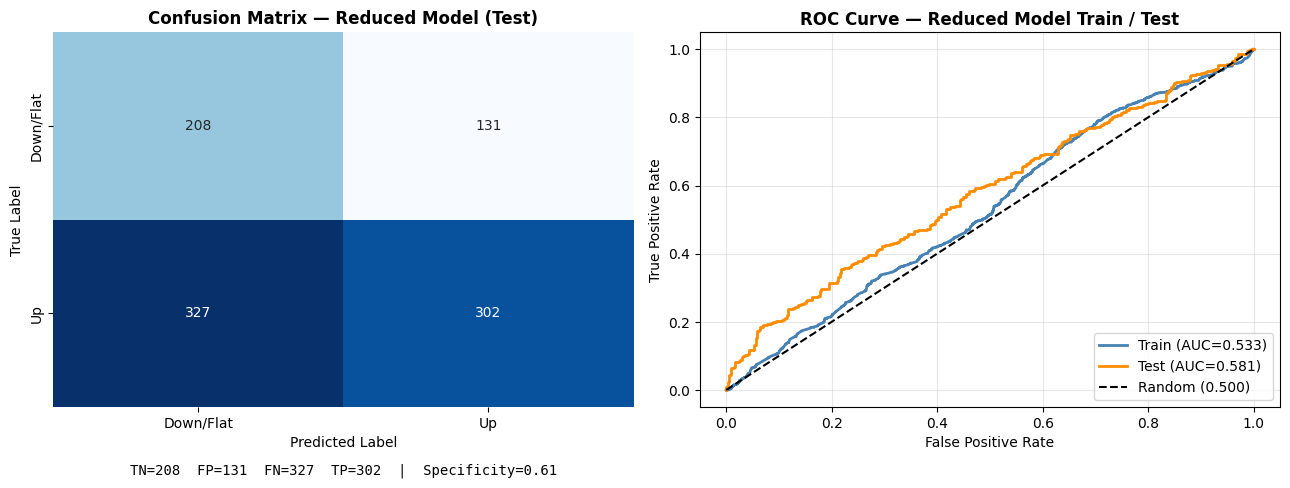

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm2 = confusion_matrix(y2_test, y2_test_pred)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Down/Flat', 'Up'],
            yticklabels=['Down/Flat', 'Up'])
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].set_title('Confusion Matrix — Reduced Model (Test)', fontweight='bold')
tn, fp, fn, tp = cm2.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
axes[0].text(0.5, -0.18,
             f'TN={tn}  FP={fp}  FN={fn}  TP={tp}  |  Specificity={specificity:.2f}',
             transform=axes[0].transAxes, ha='center', fontsize=10, family='monospace')

for y2_true, y2_prob, label, color in [
    (y2_train, best_rf2.predict_proba(X2_train)[:, 1], 'Train', 'steelblue'),
    (y2_test,  y2_test_proba,                           'Test',  'darkorange'),
]:
    fpr, tpr, _ = roc_curve(y2_true, y2_prob)
    auc = roc_auc_score(y2_true, y2_prob)
    axes[1].plot(fpr, tpr, lw=2, label=f'{label} (AUC={auc:.3f})', color=color)

axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random (0.500)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Reduced Model Train / Test', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Prediction confidence

High confidence (prob ≥ 0.7 or ≤ 0.3) : 458  (47.3%)
Low  confidence (0.3 < prob < 0.7)     : 510  (52.7%)

Accuracy — high confidence: 0.6594
Accuracy — low  confidence: 0.5529


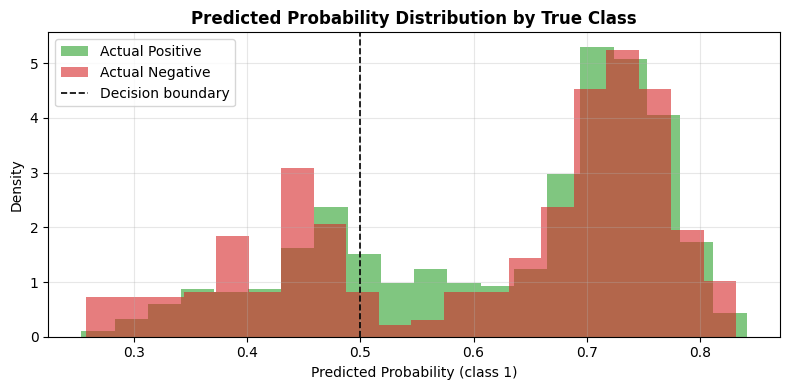

In [41]:
results_df = pd.DataFrame({
    'Actual':      y_test.values,
    'Predicted':   y_test_pred,
    'Probability': y_test_proba,
    'Correct':     y_test.values == y_test_pred
})

high_conf = (results_df['Probability'] >= 0.7) | (results_df['Probability'] <= 0.3)
low_conf  = ~high_conf

print(f"High confidence (prob ≥ 0.7 or ≤ 0.3) : {high_conf.sum()}  ({high_conf.mean()*100:.1f}%)")
print(f"Low  confidence (0.3 < prob < 0.7)     : {low_conf.sum()}  ({low_conf.mean()*100:.1f}%)")
print(f"\nAccuracy — high confidence: {results_df[high_conf]['Correct'].mean():.4f}")
print(f"Accuracy — low  confidence: {results_df[low_conf]['Correct'].mean():.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
for label, color, name in [(1, '#2ca02c', 'Actual Positive'), (0, '#d62728', 'Actual Negative')]:
    ax.hist(results_df[results_df['Actual'] == label]['Probability'],
            bins=20, alpha=0.6, color=color, label=name, density=True)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.2, label='Decision boundary')
ax.set_xlabel('Predicted Probability (class 1)')
ax.set_ylabel('Density')
ax.set_title('Predicted Probability Distribution by True Class', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Reasons to prioritize ROC-AUC: 

- Classes are imbalanced. If 60% of days are "Up", a model that always predicts "Up" gets 0.60 accuracy while doing nothing useful. ROC-AUC would correctly score that model at 0.50 — random.
- Accuracy depends on a fixed threshold (0.5). ROC-AUC evaluates the model at every threshold, so it measures the underlying probability ranking quality, not just one arbitrary cutoff.

In [ ]:
# Determine better model by ROC-AUC
full_auc = roc_auc_score(y_test,  y_test_proba)
red_auc  = roc_auc_score(y2_test, y2_test_proba)

if red_auc >= full_auc:
    best_model = best_rf2
    best_features = FEATURES_FINAL
    best_X_train = X2_train
    best_X_test = X2_test
    best_y_train = y2_train
    best_y_test = y2_test
    best_test_pred = y2_test_pred
    best_test_proba = y2_test_proba
    best_label = f"Reduced ({len(FEATURES_FINAL)} feat)"
else:
    best_model = best_rf
    best_features = FEATURES
    best_X_train = X_train
    best_X_test = X_test
    best_y_train = y_train
    best_y_test = y_test
    best_test_pred = y_test_pred
    best_test_proba = y_test_proba
    best_label = f"Full ({len(FEATURES)} feat)"

gap = accuracy_score(best_y_train, best_model.predict(best_X_train)) - \
      accuracy_score(best_y_test,  best_test_pred)

feat_imp_best = pd.DataFrame({
    'Feature': best_features,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("=" * 30)
print("RANDOM FOREST — FINAL SUMMARY")
print("=" * 30)
print(f"  Selected model    : {best_label}  (higher ROC-AUC)")
print(f"  Features          : {best_features}")
print(f"  Train / Test      : {len(best_X_train)} / {len(best_X_test)}")
print(f"  Test Accuracy     : {accuracy_score(best_y_test, best_test_pred):.4f}")
print(f"  Test F1           : {f1_score(best_y_test, best_test_pred):.4f}")
print(f"  Test ROC-AUC      : {roc_auc_score(best_y_test, best_test_proba):.4f}")
print(f"  Top feature       : {feat_imp_best.iloc[0]['Feature']} ({feat_imp_best.iloc[0]['Importance']:.4f})")
print(f"  Overfitting gap   : {gap:.4f}")
print("=" * 30)

RANDOM FOREST — FINAL SUMMARY
  Selected model    : Reduced (8 feat)  (higher ROC-AUC)
  Features          : ['MACD_Signal', 'ATR_Pct', 'BB_Width', 'CCI', 'SMA20_Dist', 'RSI_lag1', 'ROC_roll5_mean', 'Stoch_K']
  Train / Test      : 4513 / 968
  Test Accuracy     : 0.5269
  Test F1           : 0.5687
  Test ROC-AUC      : 0.5807
  Top feature       : ATR_Pct (0.2247)
  Overfitting gap   : -0.0070


/home/danila/BasicStockPricePrediction/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


## Conclusions

**Discrimination improved after feature reduction.**
Dropping `Volume_Ratio` and retraining lifted ROC-AUC from 0.525 to 0.581 — the most meaningful gain across all experiments. The model now ranks probabilities more reliably, even though raw accuracy fell slightly.

**Overfitting is essentially gone.**
A train–test gap of −0.007 means the model performs marginally *better* on unseen data than on training data. For a financial dataset this is a healthy sign — the model has stopped memorising and is generalising cleanly.

**Volatility now leads, momentum follows.**
`ATR_Pct` replaced `MACD_Signal` as the top feature (22% importance), suggesting the model finds more signal in how much the price moves than in which direction momentum points. This is consistent with volatility clustering in equity returns.

**The 30-day horizon remains the structural ceiling.**
A ROC-AUC of 0.58 is a genuine result for monthly direction forecasting with technical indicators alone, but the predictive edge is still modest. The signal in RSI, Stochastics, and MACD decays well before the 30-day target is realised.